# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [ ]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import wordcloud
from datasets import load_dataset

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [77]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [78]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA,Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS...,https://www.reuters.com/article/brief-teva-says-fremanezumab-marketing-a/brief-teva-says-fremane...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught up to other industries,The head of the Centers for Medicare and Medicaid Services said Monday it's time that health car...,https://www.cnbc.com/2018/04/30/cms-verma-says-its-time-health-care-caught-up-to-other-industrie...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining' search for his replacement | TheHill,"Benchmark, the venture capital firm that helped push Travis Kalanick out of Uber, told the compa...",https://thehill.com/policy/technology/346520-uber-investors-accuse-travis-kalanick-of-underminin...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican Pro Football Debut (Video),VIVA OCHOCINCO!!!!! Chad Johnson made his triumphant return to pro football this weekend -- IN M...,https://www.tmz.com/2017/04/03/chad-johnson-mexico-football-video/,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend that weaponizes optimism","Literary and artistic movements often arise spontaneously, out of specific moments — as a respon...",https://www.vox.com/2018/12/27/18137571/what-is-hopepunk-noblebright-grimdark,NaN,Vox


In [79]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [142]:
# TODO: Analice datos faltantes por columna
# Returns a count of missing values for every column
print("Cantidad de datos faltantes por columna:")
df.isna().sum()


Cantidad de datos faltantes por columna:


idx                0
article_idx        0
date               0
year               0
month              0
day                0
author         11405
title              0
article         1176
url              141
section        10232
publication      141
dtype: int64

In [83]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Tome los 5 medios con más artículos
top5 = df['publication'].dropna().value_counts().head(5).index
print('Los 5 medios con más artículos son:')
print(top5)
# top_5_publications = ...
df_top_5 = df[df['publication'].isin(top5)]
print('Cantidad de articulos de los 5 medios mas populares:')
len(df_top_5)

Los 5 medios con más artículos son:
Index(['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People'], dtype='str', name='publication')
Cantidad de articulos de los 5 medios mas populares:


18771

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

KeyError: 'column_x'

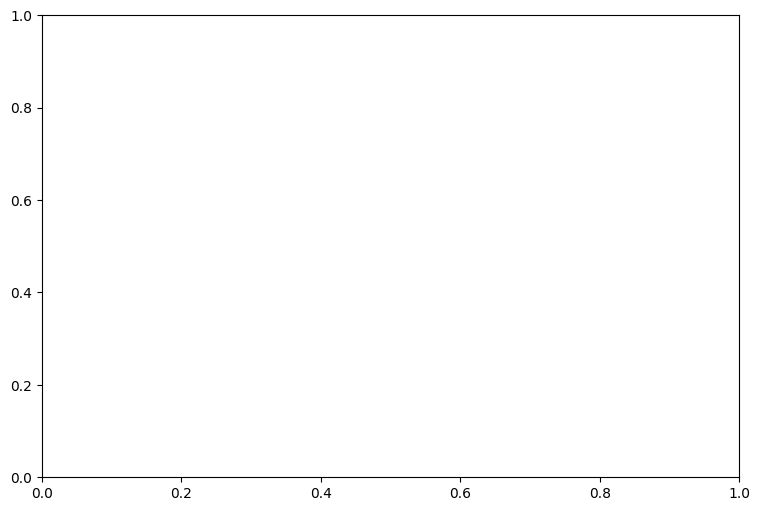

In [ ]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.

df['date'] = pd.to_datetime(df['date'], errors='coerce', format= 'mixed')
df['date'].isna().sum()

# Recreate df_top_5 after date conversion to ensure dates are datetime objects
df_top_5 = df[df['publication'].isin(top5)]
df_top_5 = df_top_5[df_top_5['date'].notna()]
df_top_5['month'] = df_top_5['date'].dt.to_period('M')

counts = (
    df_top_5
    .groupby(['month', 'publication'])
    .size()
    .unstack(fill_value=0)
)

counts.index = counts.index.to_timestamp()

counts = counts[:-1]
counts.plot(figsize=(9,6))
# Name axis, title and legend
plt.xlabel('Fecha')
plt.ylabel('Cantidad de artículos')
plt.title('Cantidad de artículos de los 5 medios más populares a lo largo del tiempo')
plt.legend(title='Medio de prensa')

Momento de mayor actividad: A partir de enero de 2020. Razones politicas.

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [130]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Handle common contractions before removing punctuation
    result = result.str.replace(r"I'm", "I am", regex=True)
    result = result.str.replace(r"you're", "you are", regex=True)
    result = result.str.replace(r"he's", "he is", regex=True)
    result = result.str.replace(r"she's", "she is", regex=True)
    result = result.str.replace(r"it's", "it is", regex=True)
    result = result.str.replace(r"we're", "we are", regex=True)
    result = result.str.replace(r"they're", "they are", regex=True)
    result = result.str.replace(r"I've", "I have", regex=True)
    result = result.str.replace(r"you've", "you have", regex=True)
    result = result.str.replace(r"we've", "we have", regex=True)
    result = result.str.replace(r"they've", "they have", regex=True)
    result = result.str.replace(r"can't", "cannot", regex=True)
    result = result.str.replace(r"won't", "will not", regex=True)
    result = result.str.replace(r"don't", "do not", regex=True)
    result = result.str.replace(r"doesn't", "does not", regex=True)

    # TODO: completar signos de puntuación faltantes (removed "'" since handled above)
    for punc in ["[", "\n", ",", ":", "?", "!", "(", ")", '"', "]"]:
        result = result.str.replace(punc, " ")

    return result

In [132]:
# TODO: Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

CleanText = clean_text(df_top_5, "article")

# Add CleanText as a new column to df_top_5
df_top_5['CleanText'] = CleanText
# print(df_top_5['CleanText'].head(n=5))
print(df_top_5.head(n=5))

   idx  article_idx       date  year    month day          author  \
0    1            1 2018-02-02  2018  2018-02   2             NaN   
1    2            2 2018-05-01  2018  2018-05   1             NaN   
2    3            3 2017-08-14  2017  2017-08  14  Harper Neidig    
5    6            6 2019-03-29  2019  2019-03  29             NaN   
6    7            7 2018-12-04  2018  2018-12   4             NaN   

                                                                                  title  \
0      BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA   
1                   CMS' Verma says it’s time health care caught up to other industries   
2  Uber investor accuses Kalanick of 'undermining' search for his replacement | TheHill   
5              UPDATE 2-Magellan Health bows to Starboard pressure, names four to board   
6                           Bank of Montreal's quarterly earnings beat market forecasts   

                                      


Agregamos: "!", "(", ")", '"', "'", "]" pues pueden ser escritos enseguida luego de una palabra
Deducimos que "." no seria conveniente remover porque "U.S" podria ser confundido con el pronombre "us".

you minglei is a name but it can be confused with the pronoun "you"
is it ok to keep the reuters header?
some of them start with a space
maybe apply the clean_text to title?

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

*TODO: Escriba su análisis en el informe.*

Conviene trabjar con una combinacion de ambos pues la eleccion de palabras es muy importante en el titulo para captar la atencion del lector. 

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [ ]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

La URL de todos las publicaciones indican el medio de prensa de forma directa.
El formato de la fecha da una indicacion pues cada medio utiliza un formato especifico. 
Luego, existen otros indicadores en los titulos y articulos como se ve a continuacion:

In [117]:
# Reuters 

df_reuters = df[df['publication'] == 'Reuters']
print('Number of articles from Reuters: {}'.format(len(df_reuters)))

# En la seccion 'article'
df_reuters_with_word_reuters = df_reuters[df_reuters['article'].str.contains('Reuters', case=False, na=False)]
print('Number of publications from Reuters containing the word "Reuters" in the article: {}'.format(len(df_reuters_with_word_reuters)))

# En la seccion 'title'
df_reuters_with_word_brief = df_reuters[df_reuters['title'].str.contains('brief', case=False, na=False)]
print('Number of publications from Reuters containing the word "brief" in the title: {}'.format(len(df_reuters_with_word_brief)))

# Publicaciones con la palabra "Reuters" en el artículo y "brief" en el título

print('Articles from Reuters containing the word "Reuters" in the article')
display(df_reuters_with_word_reuters)

print('Articles from Reuters containing the word "brief" in the title')
display(df_reuters_with_word_brief)

Number of articles from Reuters: 9431
Number of publications from Reuters containing the word "Reuters" in the article: 8724
Number of publications from Reuters containing the word "brief" in the title: 2375
Articles from Reuters containing the word "Reuters" in the article


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA,Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS...,https://www.reuters.com/article/brief-teva-says-fremanezumab-marketing-a/brief-teva-says-fremane...,Healthcare,Reuters
6,7,7,2018-12-04,2018,12.0,4,NaN,Bank of Montreal's quarterly earnings beat market forecasts,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on Tuesday reported a 19 percent increase in fourth ...",https://www.reuters.com/article/bmo-results/bank-of-montreals-quarterly-earnings-beat-market-for...,Company News,Reuters
15,16,16,2016-10-25,2016,10.0,25,Liz Hampton,Crude market takes U.S. Seaway pipeline outage in stride,HOUSTON (Reuters) - An outage on a major pipeline from the largest oil hub in the United States ...,http://www.reuters.com/article/us-pipeline-operations-enterprise-prodt-idUSKCN12P2MP,Commodities,Reuters
18,19,19,2017-10-02,2017,10.0,2,"Niklas Pollard, Ben Hirschler",How we tick: U.S. 'body clock' scientists win Nobel medicine prize,"STOCKHOLM/LONDON (Reuters) - U.S. scientists Jeffrey Hall, Michael Rosbash and Michael Young wo...",https://www.reuters.com/article/us-nobel-prize-medicine/how-we-tick-us-body-clock-scientists-win...,Science News,Reuters
23,24,24,2018-03-28,2018,3.0,28,Nellie Peyton,"Sierra Leone election raises hopes for girls' education, safe abortions",DAKAR (Thomson Reuters Foundation) - A change of president in Sierra Leone will bring a new chan...,https://www.reuters.com/article/us-leone-election-women/sierra-leone-election-raises-hopes-for-g...,Big Story 10,Reuters
...,...,...,...,...,...,...,...,...,...,...,...,...
30201,30202,30202,2020-03-24,2020,3.0,24,NaN,UK mall owner Intu to cut service charges for tenants,March 24 (Reuters) - Trafford Centre owner Intu Properties will lower its service charges for te...,https://www.reuters.com/article/health-coronavirus-intu-prop/uk-mall-owner-intu-to-cut-service-c...,Financials,Reuters
30202,30203,30203,2016-11-10,2016,11.0,10,NaN,BRIEF-Syndax Pharmaceuticals reports Q3 loss per share of $0.84,Nov 10 (Reuters) - Syndax Pharmaceuticals Inc : * Syndax Pharmaceuticals reports third quarter 2...,http://www.reuters.com/article/idUSASC09I1P,Market News,Reuters
30205,30206,30206,2017-03-01,2017,3.0,1,NaN,Kremlin says patiently waiting for U.S. policy action on Russia,MOSCOW (Reuters) - The Kremlin is patiently waiting for U.S. policy action on Russia so that it ...,http://www.reuters.com/article/us-usa-trump-russia-kremlin-idUSKBN1683SP,World News,Reuters
30206,30207,30207,2017-04-18,2017,4.0,18,NaN,BRIEF-United Financial Bancorp reports Q1 earnings per share $0.27,April 18 (Reuters) - United Financial Bancorp Inc- * United Financial Bancorp Inc announces firs...,http://www.reuters.com/article/brief-united-financial-bancorp-reports-q-idUSASA09J3I,Market News,Reuters


Articles from Reuters containing the word "brief" in the title


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA,Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS...,https://www.reuters.com/article/brief-teva-says-fremanezumab-marketing-a/brief-teva-says-fremane...,Healthcare,Reuters
27,28,28,2017-02-16,2017,2.0,16,NaN,BRIEF-DaVita Q4 adjusted earnings per share $0.98,Feb 16 (Reuters) - DaVita Inc : * DaVita Inc. 4Th quarter 2016 results * Q4 earnings per share $...,http://www.reuters.com/article/idUSASB0B0V5,Market News,Reuters
30,31,31,2017-08-07,2017,8.0,7,NaN,BRIEF-Lushang Property's units win land auctions for a combined 350.2 mln yuan,Aug 7 (Reuters) - Lushang Property Co Ltd * Says units win land auctions for a combined 350.2 mi...,https://www.reuters.com/article/brief-lushang-propertys-units-win-land-a/brief-lushang-propertys...,Financials,Reuters
52,53,53,2017-06-01,2017,6.0,1,NaN,BRIEF-Wendel pursues divestment of Saint-Gobain with shares sale,June 1 (Reuters) - France-based listed investment group Wendel says: * Says will sell 20 million...,http://www.reuters.com/article/brief-wendel-pursues-divestment-of-saint-idUSFWN1IY0NM,Financials,Reuters
67,68,68,2018-03-15,2018,3.0,15,NaN,BRIEF-Ricebran Technologies Reports Q4 Sales Fell 3 Percent To $3.1 Million,March 15 (Reuters) - Ricebran Technologies: * OPERATING LOSS OF $1.79 MILLION IN 2017 Q4 IMPROVE...,https://www.reuters.com/article/brief-ricebran-technologies-reports-q4-s/brief-ricebran-technolo...,Company News,Reuters
...,...,...,...,...,...,...,...,...,...,...,...,...
30183,30184,30184,2017-08-23,2017,8.0,23,NaN,BRIEF-Chromadex's units enter asset purchase agreement with Covance Laboratories Inc​,"Aug 23 (Reuters) - Chromadex Corp * Chromadex Corp - ‍on august 21, 2017, co’s units entered int...",https://www.reuters.com/article/brief-chromadexs-units-enter-asset-purch/brief-chromadexs-units-...,Market News,Reuters
30184,30185,30185,2016-06-14,2016,6.0,14,NaN,BRIEF-GeoPark initiates drilling campaign in Colombia,June 14 (Reuters) - Geopark Ltd : * GeoPark initiates drilling campaign in Colombia Source text ...,http://www.reuters.com/article/idUSASC08TZ3,Market News,Reuters
30202,30203,30203,2016-11-10,2016,11.0,10,NaN,BRIEF-Syndax Pharmaceuticals reports Q3 loss per share of $0.84,Nov 10 (Reuters) - Syndax Pharmaceuticals Inc : * Syndax Pharmaceuticals reports third quarter 2...,http://www.reuters.com/article/idUSASC09I1P,Market News,Reuters
30206,30207,30207,2017-04-18,2017,4.0,18,NaN,BRIEF-United Financial Bancorp reports Q1 earnings per share $0.27,April 18 (Reuters) - United Financial Bancorp Inc- * United Financial Bancorp Inc announces firs...,http://www.reuters.com/article/brief-united-financial-bancorp-reports-q-idUSASA09J3I,Market News,Reuters


In [119]:
# People

df_people = df[df['publication'] == 'People']
display(df_people)

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
47,48,48,2016-10-31 17:20:00,2016,10.0,31,Karen Mizoguchi,Hayley Hasselhoff Goes Braless for Alien Goddess Costume,Hayley Hasselhoff went out-of-this-world for Halloween. The 24-year-old daughter of David Hassel...,https://people.com/style/hayley-hasselhoff-braless-alien-goddess-costume-halloween/,style,People
59,60,60,2016-02-03 15:25:00,2016,2.0,3,Chris Harris,Bernie and Ruth Madoff's Antique Jewelry Being Sold at Online Auction,"Nearly $100,000 in jewelry that once belonged to convicted financier Bernie Madoff and his wife,...",https://people.com/crime/bernie-and-ruth-madoffs-antique-jewelry-being-sold-at-online-auction/,crime,People
79,80,80,2016-11-08 10:28:00,2016,11.0,8,Jillian Ruffo,Kris Jenner Has a Lower Back Tattoo,This year has been a big one for the KarJenners’ tattoo collection — specifically Kendall’s “meo...,https://people.com/style/khloe-kardashian-wants-to-move-mom-kris-jenners-tramp-stamp-tattoo/,style,People
89,90,90,2018-09-06 13:20:00,2018,9.0,6,Jen Juneau,Chip Gaines and Son Share Heartwarming Smile at Doctors,A doctor’s visit is no big deal when you’ve got Daddy’s laughter to distract you! Chip Gaines an...,https://people.com/parents/joanna-gaines-chip-gaines-son-crew-doctor-visit-photo/,parents,People
167,168,168,2019-01-17 10:45:00,2019,1.0,17,Maura Hohman,Victoria Beckham Dances with Cast of Tina: The Tina Turner Musical,"Posh Spice still has the moves! Former pop star Victoria Beckham, 44, attended the London perfor...",https://people.com/style/watch-victoria-beckham-dance-cast-of-tina-turner-musical/,style,People
...,...,...,...,...,...,...,...,...,...,...,...,...
30134,30135,30135,2018-03-05 16:34:00,2018,3.0,5,Thatiana Diaz,Guillermo Del Toro Stands Up for Mexico After Oscars Win,Mexican director Guillermo del Toro went into the 90th annual Academy Awards on March 4 with the...,https://people.com/chica/guillermo-del-toro-stands-up-for-mexico-after-oscar-win/,chica,People
30149,30150,30150,2018-01-10 11:55:00,2018,1.0,10,Caroline Redmond,Todrick Hall on Celebrating New Year's Eve with Taylor Swift,"When Beyoncé gives you advice, you take it! And that’s exactly what rapper and Broadway performe...",https://people.com/music/todrick-hall-beyonce-advice-taylor-swift-new-year/,music,People
30152,30153,30153,2017-08-08 16:06:00,2017,8.0,8,Mike Miller,Amber Heard Speaks Out on Split from Elon Musk: We 'Care Deeply for One Another and Remain Close',Amber Heard is opening up about her split from Elon Musk . After initially announcing the breaku...,https://people.com/movies/amber-heard-speaks-out-on-split-from-elon-musk-we-care-deeply-for-one-...,movies,People
30176,30177,30177,2016-05-05 20:28:00,2016,5.0,5,Alex Apatoff,Michael Strahan's Clothing Line for JCPenney: Go Behind the Scenes,Just because Michael Strahan is establishing himself as a clothing designer doesn’t mean his kid...,https://people.com/style/michael-strahan-cant-endorse-a-super-skinny-jean/,style,People


Parece ser que People solo escribe articulos sobre personas famosas. Los titulos siempre empiezan con el nombre y apellido de la persona en cuestion, o quizas un "How", "When" y luego el nombre de la persona. 

Ademas, el titulo solo contiene palabras en mayuscula salvo conectores ("for", "and").

Se podria chequear ambas caracteristicas en los titulos y asi deducir que la publicacion viene de esta empresa.

O encontrar una lista de las personas mas mencionadas en los medios y usarla para descubir si alguna de las tres primeras palabras del articulo coinciden con un item de dicha lista. 

In [120]:
# CNBC
# Configure pandas to show full text content
pd.set_option('display.max_colwidth', 100)

df_cnbc = df[df['publication'] == 'CNBC']
# display(df_cnbc)

display(df_cnbc['article'])
display(len(df_cnbc))
df_cnbc_with_no_author = df_cnbc[df_cnbc['author'].isna()]
display(len(df_cnbc_with_no_author))

1        The head of the Centers for Medicare and Medicaid Services said Monday it's time that health car...
5        (Updates with new first paragraph, adds background) March 29 (Reuters) - Magellan Health Inc sai...
12       Italy's Finance Minister, Pier Carlo Padoan, has said the country's banking system can be recapi...
40       (Adds banker comment) ANKARA, May 20 (Reuters) - Turkey's BDDK banking watchdog on Monday impose...
49       The Kremlin said on Wednesday it was "total nonsense" that Russian officials had assembled a fil...
                                                        ...                                                 
30143    Tankan@ * Nov manufacturers' sentiment index -9 vs Oct -5 * Service-sector index +12 in Nov vs O...
30172    Regardless of whether you're a recent college graduate or a more experienced millennial professi...
30190    Did your favorite movie or TV show nab an Golden Globe nomination? It's time to find out. The Ho...
30194    An aide to

2623

2600

Observation: The word Reuters appear in some articles like referencing the other company:
(Updates with new first paragraph, adds background) March 29 (Reuters) 

Casi ningun articulo tiene el autor especificado

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

Si nuestro objetivo es crear un clasificador, conviene distinguir los articulos por tematica o periodo temporal. De lo contrario el clasificador podr'ia sesgarse e identificar siempre los articulos de una tematica o periodo a un determinado medio.
Lo ideal seria comparar articulos de una misma tematica o periodo temporal para entrenar a un clasificador.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

GRAFICO DE COLUMNAS O MARIMEKKO PARA CADA MEDIO POR SEPARADO. PARA CADA MEDIO POR SEPARADO??? MAPA DE CALOR SERVIRIA???

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nicol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nicol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Palabras más frecuentes en Reuters:
said: 23790
reuters: 11138
percent: 7570
million: 6536
company: 6360
reporting: 6251
year: 6169
would: 5860
editing: 5781
new: 5775
also: 4698
last: 4610
billion: 4185
two: 3875
first: 3771
one: 3591
government: 3583
could: 3445
china: 3258
bank: 3190

Palabras más frecuentes en The New York Times:
said: 15693
new: 6750
one: 6378
would: 5840
like: 5103
people: 4677
trump: 4589
also: 4409
two: 3382
time: 3330
first: 3277
could: 3233
president: 3215
years: 3208
last: 2986
year: 2940
many: 2938
york: 2752
even: 2662
states: 2416

Palabras más frecuentes en CNBC:
said: 9765
percent: 3829
would: 3004
year: 2916
also: 2784
company: 2700
new: 2658
market: 2553
trump: 2442
one: 2086
last: 1984
could: 1958
china: 1865
people: 1824
trade: 1718
president: 1712
million: 1699
billion: 1672
according: 1643
cnbc: 1594

Palabras más frecuentes en The Hill:
trump: 10467
said: 6636
hill: 6276
president: 4651
would: 3839
house: 3654
news: 3366
new: 3205
washington: 31

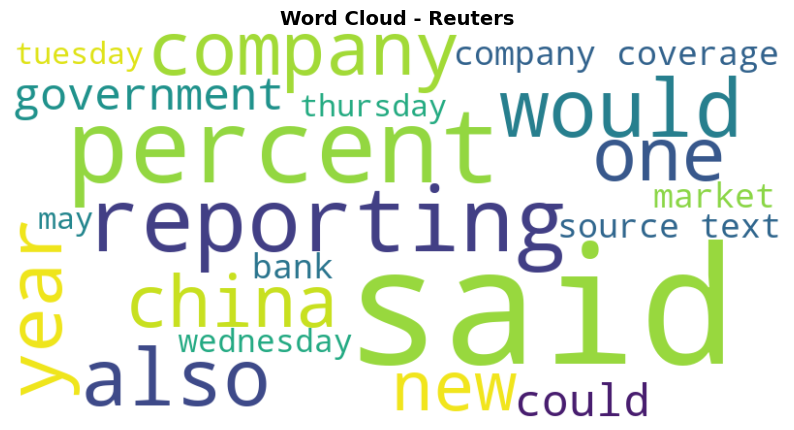

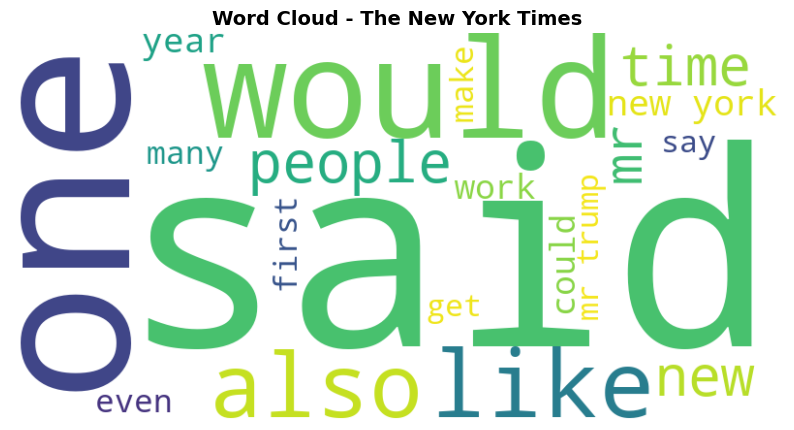

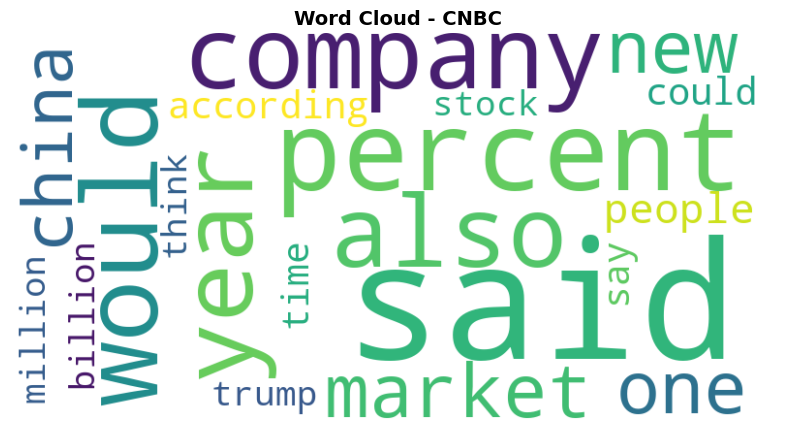

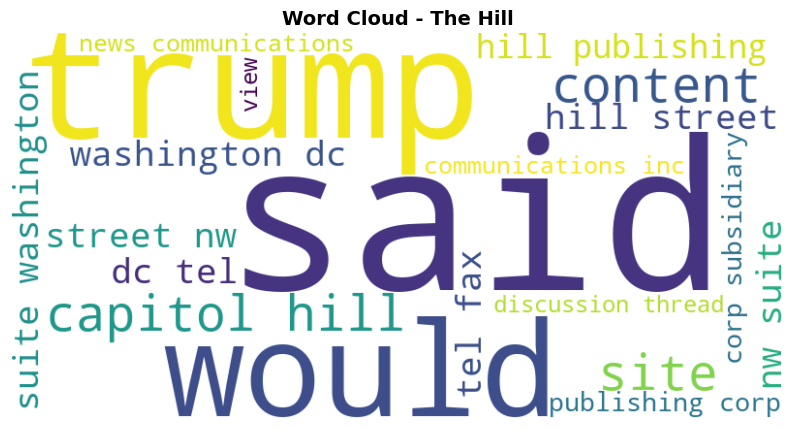

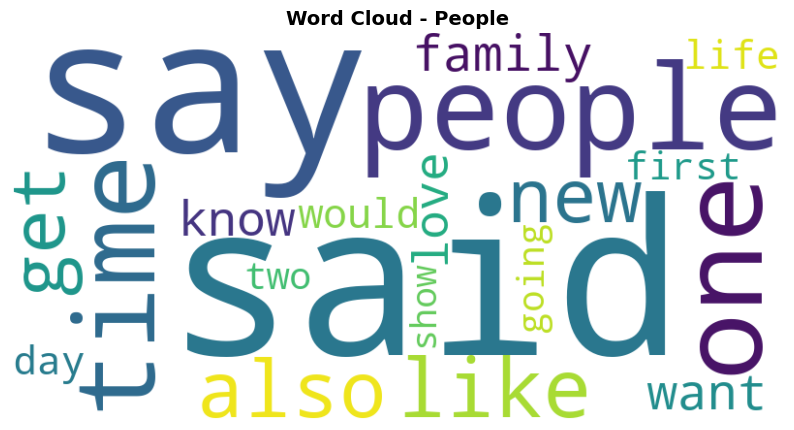

In [ ]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Descargar recursos necesarios de nltk (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')

# Función para obtener palabras más frecuentes
def get_most_frequent_words(text_series, n=20):
    # Combinar todo el texto
    all_text = ' '.join(text_series.dropna())
    
    # Tokenizar
    tokens = word_tokenize(all_text.lower())
    
    # Eliminar stopwords
    stop_words = set(stopwords.words('english'))  
    filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    
    # Contar frecuencias
    word_freq = Counter(filtered_tokens)
    
    return word_freq.most_common(n)

# Aplicar a cada medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    frequent_words = get_most_frequent_words(df_pub['CleanText'])
    
    print(f"\nPalabras más frecuentes en {publication}:")
    for word, freq in frequent_words:
        print(f"{word}: {freq}")

# Visualizacion de las 20 palabras mas frecuentes usando wordcloud, quitando las stopwords y signos de puntuacion
import matplotlib.pyplot as plt

# Create custom stopwords that includes short words from contractions
custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(['m', 's', 're', 've', 'd', 'll', 't'])  # Short words from contractions

# Crear wordclouds separados para cada medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    all_text = ' '.join(df_pub['CleanText'].dropna())
    
    # Crear wordcloud con mejores parámetros
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        max_words=20,  # Limitar a las 20 palabras más frecuentes
        colormap='viridis',
        prefer_horizontal=0.8,
        stopwords=custom_stopwords,  # Use custom stopwords with short words filtered
        min_word_length=2  # Exclude single letters like "u", "k", etc.
    ).generate(all_text)
    
    # Mostrar en figura separada
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud - {publication}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

Se podria considerar eliminar conectores como "also" y "like" y verbos ya que consideramos que los sustantivos y adjetivos demuestran mas lo que se quiere decir que este otro tipo de palabras.

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [139]:
# Imprimir la cantidad de publicaciones totales por medio
for publication in top5:
    count = len(df_top_5[df_top_5['publication'] == publication])
    print(f"Total de publicaciones en {publication}: {count}")

# Imprimir la cantidad de palabras totales por medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    total_words = df_pub['CleanText'].str.split().str.len().sum()
    print(f"Total de palabras en {publication}: {total_words}")

# Imprimir la cantidad promedio de palabras por artículo por medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    avg_words = df_pub['CleanText'].str.split().str.len().mean()
    print(f"Promedio de palabras por artículo en {publication}: {avg_words:.2f}")

Total de publicaciones en Reuters: 9431
Total de publicaciones en The New York Times: 2840
Total de publicaciones en CNBC: 2623
Total de publicaciones en The Hill: 2349
Total de publicaciones en People: 1528
Total de palabras en Reuters: 2548200.0
Total de palabras en The New York Times: 2583676.0
Total de palabras en CNBC: 1214234.0
Total de palabras en The Hill: 1350918
Total de palabras en People: 631751.0
Promedio de palabras por artículo en Reuters: 274.83
Promedio de palabras por artículo en The New York Times: 919.46
Promedio de palabras por artículo en CNBC: 471.00
Promedio de palabras por artículo en The Hill: 575.10
Promedio de palabras por artículo en People: 415.08


## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [141]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# mentions_matrix = ...

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

# Descargar recursos necesarios de nltk (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')

# Función para obtener palabras más frecuentes
def get_most_frequent_words(text_series, n=20):
    # Combinar todo el texto
    all_text = ' '.join(text_series.dropna())
    
    # Tokenizar
    tokens = word_tokenize(all_text.lower())
    
    # Eliminar stopwords
    stop_words = set(stopwords.words('english')) 
    filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    
    # Contar frecuencias
    word_freq = Counter(filtered_tokens)
    
    return word_freq['people'], word_freq['reuters'], word_freq['cnbc']

def get_frequency_of_phrases(text_series, phrases):
    # Combinar todo el texto
    nltk.ngrams(text_series, n=2)
    
    # Contar frecuencias de cada frase
    phrase_freq = {phrase: 0 for phrase in phrases}
    
    return phrase_freq

# Aplicar a cada medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    frequent_words = get_most_frequent_words(df_pub['article'])
    frequent_phrases = get_frequency_of_phrases(df_pub['article'], ['people', 'the new york times'])
    
    print(f"El medio People es mencionado {frequent_words} veces en los artículos de {publication}")
    print(f"El medio The New York Times es mencionado {frequent_phrases} veces en los artículos de {publication}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nicol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nicol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


El medio People es mencionado (2911, 11628, 44) veces en los artículos de Reuters
El medio The New York Times es mencionado {'people': 0, 'the new york times': 0} veces en los artículos de Reuters
El medio People es mencionado (4690, 50, 19) veces en los artículos de The New York Times
El medio The New York Times es mencionado {'people': 0, 'the new york times': 0} veces en los artículos de The New York Times
El medio People es mencionado (1829, 1190, 1595) veces en los artículos de CNBC
El medio The New York Times es mencionado {'people': 0, 'the new york times': 0} veces en los artículos de CNBC
El medio People es mencionado (1993, 120, 20) veces en los artículos de The Hill
El medio The New York Times es mencionado {'people': 0, 'the new york times': 0} veces en los artículos de The Hill
El medio People es mencionado (2508, 7, 5) veces en los artículos de People
El medio The New York Times es mencionado {'people': 0, 'the new york times': 0} veces en los artículos de People


In [ ]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*

Que medio es mas mencionado por otros?
Que medio menciona mas otros medios?
Que medio se autorreferncia mas? Es autoreferencia o simplemente tienen un template con su nombre?
